<a href="https://colab.research.google.com/github/sravya520/Emcet_Clg_Prediction/blob/main/SmolVLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lerobot transformers accelerate pillow

In [ ]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image
import torch


# Trained on CPU and can only generate Text not robot action as this model is VLM

In [ ]:
model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    device_map="cpu"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [ ]:
image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"
)
prompt = "Describe this image in multiple paragraphs in detail."
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]
    }
]


In [ ]:
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}
output = model.generate(**inputs, max_new_tokens=100)
print(processor.decode(output[0], skip_special_tokens=True))

User:



Describe this image in multiple paragraphs in detail.
Assistant: The image depicts two cats lying on a pink, plush, fabric surface. The cats are positioned side by side, facing each other, and appear to be resting comfortably. The cat on the left is larger and has a darker, more striped coat, while the cat on the right is smaller and lighter in color. Both cats have their tails curled around, suggesting they are either resting or sleeping.

The pink fabric surface is smooth and appears to be a soft, plush material,


# **VLA Model**

# Required Libraries

In [ ]:
!pip install "lerobot[smolvla]"
!pip install datasets

# Importing libs

In [ ]:
# import torch
from datasets import load_dataset
# from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
from lerobot.policies.factory import make_pre_post_processors

# Load SmolVLA Model

In [ ]:
import torch
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy

device = "cuda" if torch.cuda.is_available() else "cpu"

policy = SmolVLAPolicy.from_pretrained(
    "lerobot/smolvla_base"
).to(device).eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/868 [00:00<?, ?B/s]

Reducing the number of VLM layers to 16 ...


model.safetensors:   0%|          | 0.00/907M [00:00<?, ?B/s]

In [ ]:
from datasets import load_dataset

dataset = load_dataset("lerobot/pusht", split="train[:1%]")

In [ ]:
sample = dataset[0]
print(sample.keys())


dict_keys(['observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index'])


In [ ]:
sample = dataset[0]

observation = sample["observation"]
state = sample["state"]

action = policy.predict_action(
    observation=observation,
    state=state
)

print("Predicted action:", action)


KeyError: 'observation'

# Load Dataset Sample

In [ ]:
dataset1 = load_dataset("lerobot/pusht_image", split="train[:1%]")
sample1 = dataset1[0]

In [ ]:
print(type(sample))

<class 'dict'>


In [ ]:
dataset1[0].keys()

dict_keys(['observation.image', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index'])

In [ ]:
print(type(sample1["observation.image"]))
print(sample1["observation.state"])


<class 'PIL.PngImagePlugin.PngImageFile'>
[222.0, 97.0]


# Prepare Image and State

SmolVLA expects:

image size = 256×256

tensor format

batch dimension

In [ ]:
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

image = transform(sample["observation.image"])
state = torch.tensor(sample["observation.state"], dtype=torch.float32)

# Add batch dimension
image = image.unsqueeze(0).to(device)
state = state.unsqueeze(0).to(device)


In [ ]:
print(type(sample["observation.image"]))

<class 'PIL.PngImagePlugin.PngImageFile'>


# Prepare Language Instruction

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    policy.config.vlm_model_name
)

In [ ]:
instruction = "push the object to the goal"

lang = tokenizer(
    instruction,
    padding="max_length",
    truncation=True,
    max_length=policy.config.tokenizer_max_length,
    return_tensors="pt"
)

lang_tokens = lang["input_ids"].to(device)
lang_mask = lang["attention_mask"].bool().to(device)



# Build Input Batch

In [ ]:
batch = {
    "observation.state": state,
    "observation.images.camera1": image,
    "observation.images.camera2": image,
    "observation.images.camera3": image,
    "observation.language.tokens": lang_tokens,
    "observation.language.attention_mask": lang_mask,
}


In [ ]:
print(policy.config)


SmolVLAConfig(n_obs_steps=1, input_features={'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(6,)), 'observation.images.camera1': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256)), 'observation.images.camera2': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256)), 'observation.images.camera3': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 256, 256))}, output_features={'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(6,))}, device='cuda', use_amp=False, use_peft=False, push_to_hub=True, repo_id=None, private=None, tags=None, license=None, pretrained_path=None, chunk_size=50, n_action_steps=50, normalization_mapping={'VISUAL': <NormalizationMode.IDENTITY: 'IDENTITY'>, 'STATE': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'ACTION': <NormalizationMode.MEAN_STD: 'MEAN_STD'>}, max_state_dim=32, max_action_dim=32, resize_imgs_with_padding=(512, 512), empty_cameras=0, adapt_to_pi_aloha=False, us

# Run Inference
torch.no_grad() disables gradient computation

select_action() returns robot control values

In [ ]:
with torch.no_grad():
    action = policy.select_action(batch)

print("Predicted action:", action)


Predicted action: tensor([[-0.8728, -0.1689,  0.0957,  0.3284,  1.3698, -0.7469]],
       device='cuda:0')


# **Adding WEBCAM**

# Imports

In [ ]:
import cv2
import torch
import torchvision.transforms as T
import numpy as np
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

# Device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image Transform

In [ ]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.ToTensor(),
])


# Webcam Capture Function (Colab Compatible)

In [ ]:
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise(resolve => setTimeout(resolve, 1500));

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg');
        }
    ''')

    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    img = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img, cv2.IMREAD_COLOR)

    return img

# Capture Image

<IPython.core.display.Javascript object>

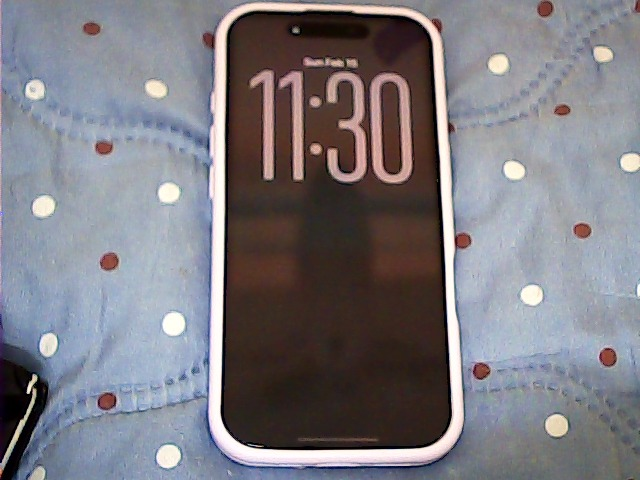

In [ ]:
frame = take_photo()
cv2_imshow(frame)

# Convert Image for Model

In [ ]:
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
image = transform(frame_rgb).unsqueeze(0).to(device)

# Prompt

In [ ]:
prompt = "Pick up the object in front of you"

# Tokenize prompt (depends on your tokenizer)

In [ ]:
lang = tokenizer(prompt, return_tensors="pt", padding=True)
lang_tokens = lang["input_ids"].to(device)
lang_mask = lang["attention_mask"].to(device)

# Dummy State (required by policy)

In [ ]:
state = torch.zeros((1, 6)).to(device)

# Prepare Batch

In [ ]:
batch = {
    "observation.state": state,
    "observation.images.camera1": image,
    "observation.images.camera2": image,
    "observation.images.camera3": image,
    "observation.language.tokens": lang_tokens,
    "observation.language.attention_mask": lang_mask,
}

# Predict Action

In [ ]:
policy.to(device)
policy.eval()

with torch.no_grad():
    action = policy.select_action(batch)

print("Predicted action:", action)

Predicted action: tensor([[-0.1983,  0.4425,  1.3267, -0.1937,  2.4690, -0.6553]],
       device='cuda:0')


# **Continues Camera**

In [ ]:
import torch
import torchvision.transforms as T
import numpy as np
import cv2
import time
from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== Image Transform =====
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.ToTensor(),
])

# ===== Prompt =====
prompt = "Pick up the object in front of you"

lang = tokenizer(prompt, return_tensors="pt", padding=True)
lang_tokens = lang["input_ids"].to(device)
lang_mask = lang["attention_mask"].to(device)

# ===== Start Camera Stream (ONLY ONCE) =====
display(Javascript('''
async function startCamera(){
    const div = document.createElement('div');
    const video = document.createElement('video');
    video.style.display = 'block';
    const stream = await navigator.mediaDevices.getUserMedia({video: true});
    video.srcObject = stream;
    await video.play();
    document.body.appendChild(video);
    window.videoElement = video;
}
startCamera();
'''))

time.sleep(2)

# ===== Function to Grab Frame =====
def get_frame():
    js = Javascript('''
        async function captureFrame(){
            const video = window.videoElement;
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg');
        }
    ''')
    display(js)
    data = eval_js("captureFrame()")
    binary = b64decode(data.split(',')[1])
    img = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img, cv2.IMREAD_COLOR)
    return img


# ===== Dummy State =====
state = torch.zeros((1, 6)).to(device)

policy.to(device)
policy.eval()

# ===== Continuous Loop =====
while True:
    frame = get_frame()

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    image = transform(frame_rgb).unsqueeze(0).to(device)

    batch = {
        "observation.state": state,
        "observation.images.camera1": image,
        "observation.images.camera2": image,
        "observation.images.camera3": image,
        "observation.language.tokens": lang_tokens,
        "observation.language.attention_mask": lang_mask,
    }

    with torch.no_grad():
        action = policy.select_action(batch)

    clear_output(wait=True)
    print("Predicted action:", action)

    time.sleep(0.3)


Predicted action: tensor([[-0.0938,  0.5835,  1.9448, -0.3090,  2.5893, -0.6249]],
       device='cuda:0')


<IPython.core.display.Javascript object>

MessageError: TypeError: Cannot read properties of undefined (reading 'videoWidth')